In [1]:
import os
# if using Apple MPS, fall back to CPU for unsupported ops
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
# select the device for computation
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"using device: {device}")

if device.type == "cuda":
    # use bfloat16 for the entire notebook
    torch.autocast("cuda", dtype=torch.bfloat16).__enter__()
    # turn on tfloat32 for Ampere GPUs (https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices)
    if torch.cuda.get_device_properties(0).major >= 8:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
elif device.type == "mps":
    print(
        "\nSupport for MPS devices is preliminary. SAM 2 is trained with CUDA and might "
        "give numerically different outputs and sometimes degraded performance on MPS. "
        "See e.g. https://github.com/pytorch/pytorch/issues/84936 for a discussion."
    )

using device: cuda


In [4]:
from sam2.build_sam import build_sam2_video_predictor

sam2_checkpoint = "./checkpoints/sam2.1_hiera_large.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_l.yaml"

predictor = build_sam2_video_predictor(model_cfg, sam2_checkpoint, device=device)

In [5]:
def show_mask(mask, ax, obj_id=None, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        cmap = plt.get_cmap("tab10")
        cmap_idx = 0 if obj_id is None else obj_id
        color = np.array([*cmap(cmap_idx)[:3], 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)


def show_points(coords, labels, ax, marker_size=200):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)


def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0, 0, 0, 0), lw=2))

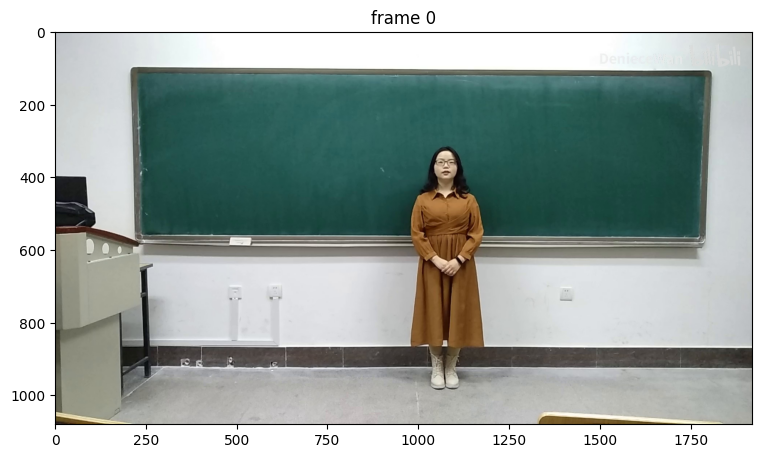

In [9]:
# `video_dir` a directory of JPEG frames with filenames like `<frame_index>.jpg`
video_dir = "./../../data/processed/visual/frames/lecture_sample"

# scan all the JPEG frame names in this directory
frame_names = [
    p for p in os.listdir(video_dir)
    if os.path.splitext(p)[-1] in [".jpg", ".jpeg", ".JPG", ".JPEG"]
]
frame_names.sort(key=lambda p: int(os.path.splitext(p)[0]))

# take a look the first video frame
frame_idx = 0
plt.figure(figsize=(9, 6))
plt.title(f"frame {frame_idx}")
plt.imshow(Image.open(os.path.join(video_dir, frame_names[frame_idx])))

In [10]:
inference_state = predictor.init_state(video_path="./../../data/processed/visual/frames/lecture_sample")

frame loading (JPEG): 100%|██████████| 78/78 [00:04<00:00, 18.07it/s]


In [38]:
predictor.reset_state(inference_state)

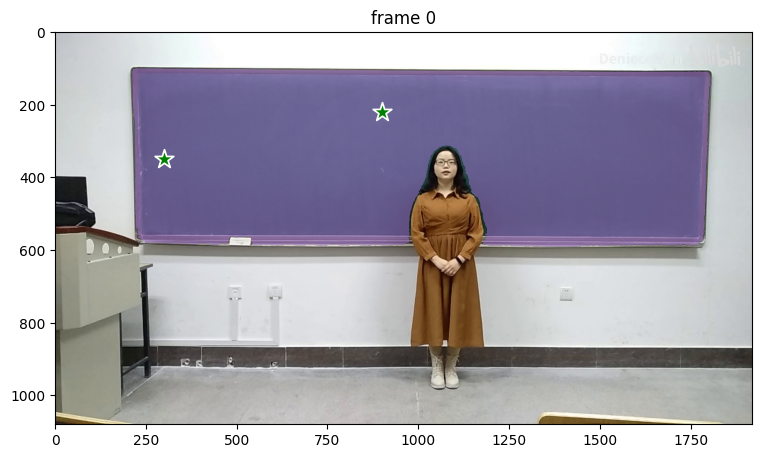

In [28]:
ann_frame_idx = 0  # the frame index we interact with
ann_obj_id = 1  # give a unique id to each object we interact with (it can be any integers)

# Let's add a 2nd positive click at (x, y) = (250, 220) to refine the mask
# sending all clicks (and their labels) to `add_new_points_or_box`
points = np.array([[300, 350], [900, 220]], dtype=np.float32)
# for labels, `1` means positive click and `0` means negative click
labels = np.array([1, 1], np.int32)
_, out_obj_ids, out_mask_logits = predictor.add_new_points_or_box(
    inference_state=inference_state,
    frame_idx=ann_frame_idx,
    obj_id=ann_obj_id,
    points=points,
    labels=labels,
)

# show the results on the current (interacted) frame
plt.figure(figsize=(9, 6))
plt.title(f"frame {ann_frame_idx}")
plt.imshow(Image.open(os.path.join(video_dir, frame_names[ann_frame_idx])))
show_points(points, labels, plt.gca())
show_mask((out_mask_logits[0] > 0.0).cpu().numpy(), plt.gca(), obj_id=out_obj_ids[0])

propagate in video: 100%|██████████| 78/78 [00:18<00:00,  4.24it/s]


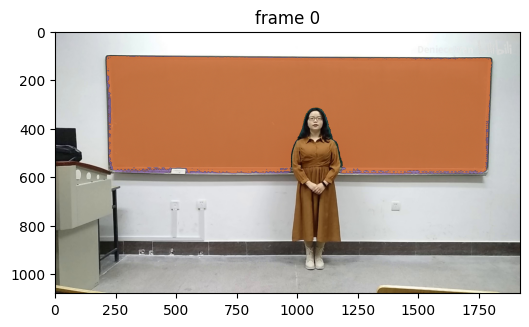

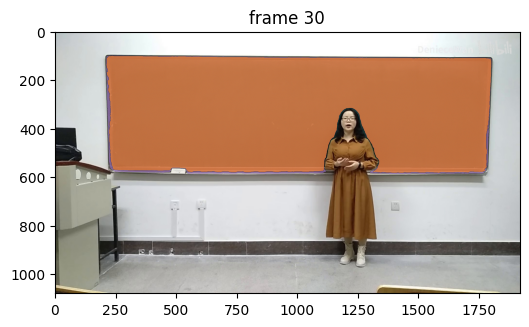

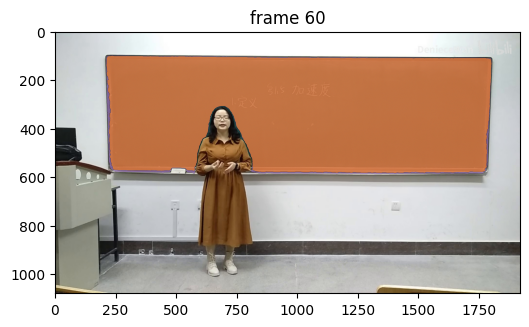

In [29]:
# run propagation throughout the video and collect the results in a dict
video_segments = {}  # video_segments contains the per-frame segmentation results
for out_frame_idx, out_obj_ids, out_mask_logits in predictor.propagate_in_video(inference_state):
    video_segments[out_frame_idx] = {
        out_obj_id: (out_mask_logits[i] > 0.0).cpu().numpy()
        for i, out_obj_id in enumerate(out_obj_ids)
    }

# render the segmentation results every few frames
vis_frame_stride = 30
plt.close("all")
for out_frame_idx in range(0, len(frame_names), vis_frame_stride):
    plt.figure(figsize=(6, 4))
    plt.title(f"frame {out_frame_idx}")
    plt.imshow(Image.open(os.path.join(video_dir, frame_names[out_frame_idx])))
    for out_obj_id, out_mask in video_segments[out_frame_idx].items():
        show_mask(out_mask, plt.gca(), obj_id=out_obj_id)

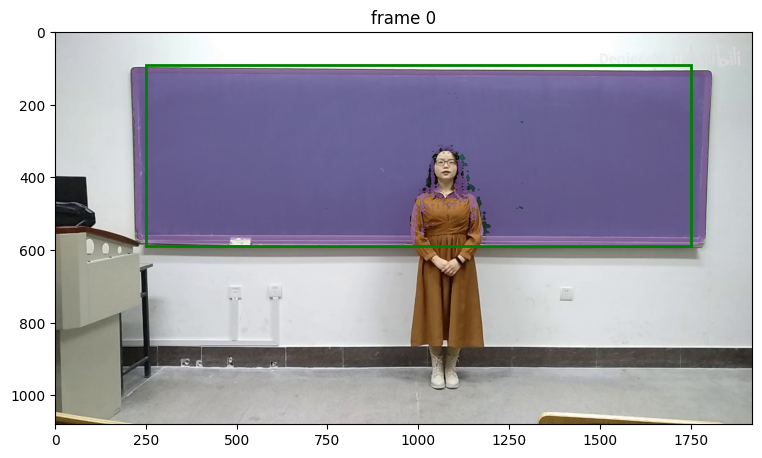

In [13]:
ann_frame_idx = 0  # the frame index we interact with
ann_obj_id = 4  # give a unique id to each object we interact with (it can be any integers)

# Let's add a box at (x_min, y_min, x_max, y_max) = (300, 0, 500, 400) to get started
box = np.array([250, 90, 1750, 590], dtype=np.float32)
_, out_obj_ids, out_mask_logits = predictor.add_new_points_or_box(
    inference_state=inference_state,
    frame_idx=ann_frame_idx,
    obj_id=ann_obj_id,
    box=box,
)

# show the results on the current (interacted) frame
plt.figure(figsize=(9, 6))
plt.title(f"frame {ann_frame_idx}")
plt.imshow(Image.open(os.path.join(video_dir, frame_names[ann_frame_idx])))
show_box(box, plt.gca())
show_mask((out_mask_logits[0] > 0.0).cpu().numpy(), plt.gca(), obj_id=out_obj_ids[0])

propagate in video: 100%|██████████| 78/78 [00:18<00:00,  4.23it/s]


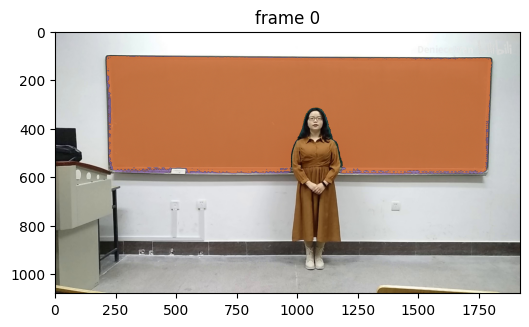

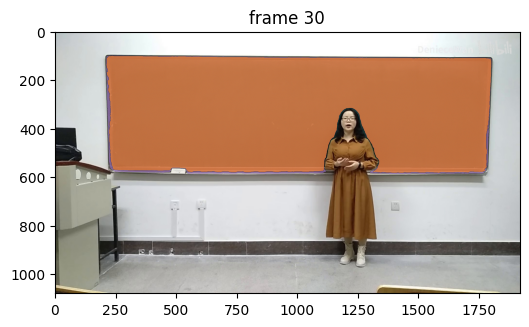

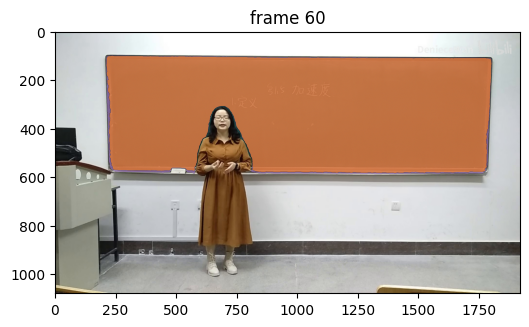

In [23]:
# run propagation throughout the video and collect the results in a dict
video_segments = {}  # video_segments contains the per-frame segmentation results
for out_frame_idx, out_obj_ids, out_mask_logits in predictor.propagate_in_video(inference_state):
    video_segments[out_frame_idx] = {
        out_obj_id: (out_mask_logits[i] > 0.0).cpu().numpy()
        for i, out_obj_id in enumerate(out_obj_ids)
    }

# render the segmentation results every few frames
vis_frame_stride = 30
plt.close("all")
for out_frame_idx in range(0, len(frame_names), vis_frame_stride):
    plt.figure(figsize=(6, 4))
    plt.title(f"frame {out_frame_idx}")
    plt.imshow(Image.open(os.path.join(video_dir, frame_names[out_frame_idx])))
    for out_obj_id, out_mask in video_segments[out_frame_idx].items():
        show_mask(out_mask, plt.gca(), obj_id=out_obj_id)

In [27]:
output_dir = "./../../data/processed/visual/masks/blackboard_crops"
os.makedirs(output_dir, exist_ok=True)

# 步长：保持与你可视化时一致 (如果想每帧都存，改为 1)
save_stride = vis_frame_stride 

file_counter = 0
target_obj_id = ann_obj_id 

# 获取参考图像尺寸 (用于边界检查和裁剪)
# 假设 frame_names 和 video_dir 已定义
ref_img_path = os.path.join(video_dir, frame_names[0])
ref_img = Image.open(ref_img_path)
ref_w, ref_h = ref_img.size # PIL returns (width, height)
print(f"参考图像尺寸: {ref_w}x{ref_h} (W x H)")
print(f"开始保存裁剪图像到: {os.path.abspath(output_dir)}")

sorted_frame_indices = sorted(video_segments.keys())
saved_count = 0
skip_count = 0

for frame_idx in sorted_frame_indices:
    # 步长过滤
    if frame_idx % save_stride != 0:
        continue
        
    frame_data = video_segments[frame_idx]
    
    if target_obj_id not in frame_data:
        skip_count += 1
        continue

    mask = frame_data[target_obj_id]
    
    # --- 数据标准化处理 ---
    if isinstance(mask, torch.Tensor):
        mask_np = mask.cpu().numpy()
    else:
        mask_np = mask
        
    # 确保是 2D (H, W)
    if len(mask_np.shape) == 3:
        # 如果是 (1, H, W)
        if mask_np.shape[0] == 1:
            mask_np = mask_np[0]
        # 如果是 (H, W, 1)
        elif mask_np.shape[-1] == 1:
            mask_np = mask_np[:, :, 0]
        else:
            # 未知 3D 情况，跳过
            print(f"帧 {frame_idx}: 未知的 Mask 形状 {mask_np.shape}，跳过。")
            continue
            
    if len(mask_np.shape) != 2:
        print(f"帧 {frame_idx}: Mask 不是 2D 数组，跳过。")
        continue

    # 二值化
    mask_binary = mask_np > 0.5
    
    # --- 计算边界框 ---
    rows = np.any(mask_binary, axis=1) # 形状 (H,)
    cols = np.any(mask_binary, axis=0) # 形状 (W,)
    
    if not np.any(rows) or not np.any(cols):
        skip_count += 1
        continue
        
    y_indices = np.where(rows)[0]
    x_indices = np.where(cols)[0]
    
    y_min, y_max = y_indices[0], y_indices[-1]
    x_min, x_max = x_indices[0], x_indices[-1]
    
    # --- 有效性检查 (防止出现高度为1的异常) ---
    if (y_max - y_min) < 2 or (x_max - x_min) < 2:
        print(f"帧 {frame_idx}: 警告 - 检测到的物体太小 (H:{y_max-y_min}, W:{x_max-x_min})，跳过。")
        skip_count += 1
        continue

    # --- 添加边距 (Padding) ---
    padding = 10
    x_min = max(0, x_min - padding)
    y_min = max(0, y_min - padding)
    x_max = min(ref_w, x_max + padding)
    y_max = min(ref_h, y_max + padding)
    
    # --- 裁剪与保存 ---
    img_path = os.path.join(video_dir, frame_names[frame_idx])
    try:
        full_image = Image.open(img_path).convert("RGB")
    except Exception as e:
        print(f"帧 {frame_idx}: 无法打开图像 {img_path}, 错误: {e}")
        continue
    
    # PIL crop: (left, upper, right, lower)
    # 注意：np.where 得到的 max 是索引，crop 的 right/lower 需要是 exclusive 的，所以 +1
    crop_box = (x_min, y_min, x_max + 1, y_max + 1)
    
    cropped_img = full_image.crop(crop_box)
    
    filename = f"{file_counter:05d}.png"
    save_path = os.path.join(output_dir, filename)
    
    cropped_img.save(save_path)
    
    saved_count += 1
    if saved_count % 10 == 1: # 每保存10张打印一次
        print(f"已保存: {filename} | 源帧: {frame_idx} | 裁剪框: {crop_box} | 物体尺寸: {x_max-x_min+1}x{y_max-y_min+1}")
    
    file_counter += 1

print("-" * 30)
print(f"处理完成！")
print(f"成功保存: {saved_count} 张图片")
print(f"跳过 (无目标或异常): {skip_count} 帧")
print(f"输出目录: {output_dir}")

参考图像尺寸: 1920x1080 (W x H)
开始保存裁剪图像到: /home/featurize/work/LessonNet/data/processed/visual/masks/blackboard_crops
已保存: 00000.png | 源帧: 0 | 裁剪框: (201, 92, 1814, 637) | 物体尺寸: 1613x545
------------------------------
处理完成！
成功保存: 3 张图片
跳过 (无目标或异常): 0 帧
输出目录: ./../../data/processed/visual/masks/blackboard_crops


In [39]:
prompts = {} # hold all the clicks we add for visualization

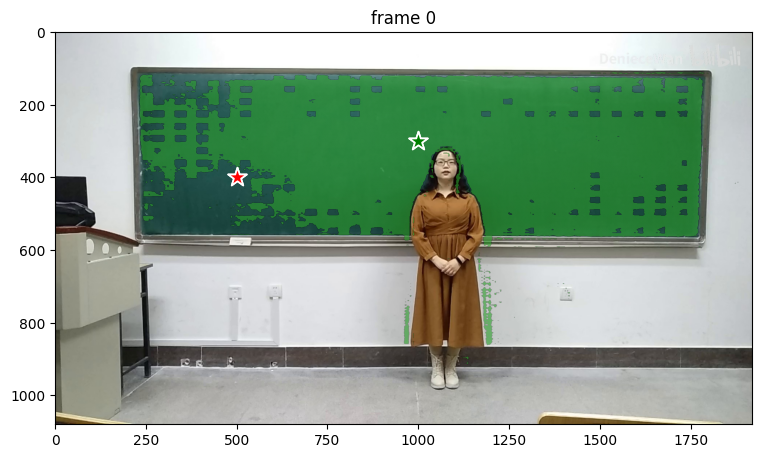

In [47]:
# add the first object
ann_frame_idx = 0  # the frame index we interact with
ann_obj_id = 2  # give a unique id to each object we interact with (it can be any integers)

# Let's add a 2nd negative click at (x, y) = (275, 175) to refine the first object
# sending all clicks (and their labels) to `add_new_points_or_box`
points = np.array([[1000, 300], [500, 400]], dtype=np.float32)
# for labels, `1` means positive click and `0` means negative click
labels = np.array([1, 0], np.int32)
prompts[ann_obj_id] = points, labels
_, out_obj_ids, out_mask_logits = predictor.add_new_points_or_box(
    inference_state=inference_state,
    frame_idx=ann_frame_idx,
    obj_id=ann_obj_id,
    points=points,
    labels=labels,
)

# show the results on the current (interacted) frame
plt.figure(figsize=(9, 6))
plt.title(f"frame {ann_frame_idx}")
plt.imshow(Image.open(os.path.join(video_dir, frame_names[ann_frame_idx])))
show_points(points, labels, plt.gca())
for i, out_obj_id in enumerate(out_obj_ids):
    show_points(*prompts[out_obj_id], plt.gca())
    show_mask((out_mask_logits[i] > 0.0).cpu().numpy(), plt.gca(), obj_id=out_obj_id)

{2: (array([[1000.,  300.],
       [ 500.,  400.]], dtype=float32), array([1, 0], dtype=int32))}
